# Итоговая работа

Работа посвящена обучению модели для классификации отзывов из Steam к игре "Clair Obscur: Expedition 33"

In [ ]:
# необходимые библиотеки
#%pip install numpy==2.3.5
#%pip install pandas==2.3.3
#%pip install stop_words==2025.11.4
#%pip install natasha
#%pip install razdel
#%pip install scikit-learn==1.7.2
#%pip intall wordcloud==1.9.4
#%matplotlib==3.9.2

In [1]:
# открываем отзывы
import pandas as pd
import numpy as np

df = pd.read_csv('exp33_crawled.csv')
df['num_of_products'] = df['num_of_products'].fillna(0)
df = df.dropna().reset_index(drop=True)
df['num_of_products'] = df['num_of_products'].astype(int)
df.head()

,nickname,rating,text,date,hours,num_of_products,helpfulCount,funnyCount,rewardCount,profile
0,Mr.Gazpach,Recommended,1) Бывший сотрудник Ubisoft уходит из компании...,2025-10-19,113.9,400,398,10,29,https://steamcommunity.com/id/gazpach/
1,djpеnis,Recommended,Техасская мазня говном,2025-12-27,93.2,539,105,0,1,https://steamcommunity.com/id/neqroneeshka/
2,W0MANM0M3NT,Recommended,"Итак, эта игра меня достала еще на Твиче, когд...",2025-08-19,242.1,302,199,6,24,https://steamcommunity.com/id/ttv-womanmoment/
3,Yaguar,Recommended,Шедевр. Потрясающее приключение. Одна из лучши...,2025-06-15,41.3,279,207,4,12,https://steamcommunity.com/id/yaguar13/
4,hud_rakoobrazniy,Recommended,Игра - A X Y Й. За меня давно уже всё расписал...,2025-06-27,95.9,293,134,135,4,https://steamcommunity.com/id/cttamepka/


In [2]:
df.shape

(10918, 10)

In [3]:
# Оказывается, что игра настолько хорошая, что положительных отзывов в 10 раз больше
df['rating'].value_counts()

rating
Recommended        10135
Not Recommended      783
Name: count, dtype: int64

In [4]:
# Уменьшим выборку до 1000 положительных и всех доступных отрицательных отзывов
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
neg_df = df[df['rating'] == 'Not Recommended']
pos_df = df[df['rating'] == 'Recommended'].iloc[:1000, :]
df = pd.concat([neg_df, pos_df], axis=0).reset_index(drop=True)
del neg_df, pos_df
df.head()

,nickname,rating,text,date,hours,num_of_products,helpfulCount,funnyCount,rewardCount,profile
0,Simiola,Not Recommended,"Игра дико переоценена! Геймплей скучный, боль...",2025-09-28,3.5,486,2,0,0,https://steamcommunity.com/profiles/7656119908...
1,Манс Розбійник,Not Recommended,overoveroverhype,2025-09-28,26.9,444,2,0,0,https://steamcommunity.com/profiles/7656119801...
2,M.W.,Not Recommended,"Начну с того, что мне понравилось: красивый ви...",2025-06-04,24.8,152,15,0,4,https://steamcommunity.com/profiles/7656119833...
3,Herzschrittmacher,Not Recommended,Говно игра,1900-04-23,40.7,0,0,0,0,https://steamcommunity.com/profiles/7656119907...
4,Joe,Not Recommended,"Как говорит Гюстав:\n""Слабовато!""",1900-02-27,0.9,164,0,0,0,https://steamcommunity.com/id/oscarputina/


In [5]:
df.shape

(1783, 10)

In [6]:
# ПРЕДОБРАБОТКА
from stop_words import get_stop_words
from razdel import tokenize
from natasha import MorphVocab
import string

STOPWORDS = get_stop_words('russian')

STOPWORDS.extend(['игра', 'сюжет', 'то', 'за', 'из', 'что', 'стать', 'понять', 'свой'])

def preproc(text: str, stopwords):
    '''Удаляет пунктуацию, токенизирует, лемматизирует и удаляет стопслова'''
    text = text.lower()
    punctuation = string.punctuation[:12] + string.punctuation[13:]
    morph = MorphVocab()
    text = ''.join([char for char in text if char not in punctuation])
    tokens = [tok.text for tok in list(tokenize(text))]
    lemmat_toks = [morph.lemmatize(tok, morph(tok)[0].pos, {}) for tok in tokens]
    final_toks = [tok for tok in lemmat_toks if tok not in stopwords]
    return final_toks

df['preproced'] = df['text'].apply(lambda x: preproc(x, STOPWORDS))
df.head()

,nickname,rating,text,date,hours,num_of_products,helpfulCount,funnyCount,rewardCount,profile,preproced
0,Simiola,Not Recommended,"Игра дико переоценена! Геймплей скучный, боль...",2025-09-28,3.5,486,2,0,0,https://steamcommunity.com/profiles/7656119908...,"[дико, переоценить, геймплей, скучный, купить,..."
1,Манс Розбійник,Not Recommended,overoveroverhype,2025-09-28,26.9,444,2,0,0,https://steamcommunity.com/profiles/7656119801...,[overoveroverhype]
2,M.W.,Not Recommended,"Начну с того, что мне понравилось: красивый ви...",2025-06-04,24.8,152,15,0,4,https://steamcommunity.com/profiles/7656119833...,"[начать, понравиться, красивый, визуал, озвучк..."
3,Herzschrittmacher,Not Recommended,Говно игра,1900-04-23,40.7,0,0,0,0,https://steamcommunity.com/profiles/7656119907...,[говно]
4,Joe,Not Recommended,"Как говорит Гюстав:\n""Слабовато!""",1900-02-27,0.9,164,0,0,0,https://steamcommunity.com/id/oscarputina/,"[говорить, гюстать, слабовато]"


In [7]:
# расчитаем среднюю длину отзывов (в словах) для каждого класса отдельно
def count_mean_words(iterable: pd.Series):
    '''Считает среднее количество слов в отзыве'''
    words_count = []
    for text in iterable:
        words_count.append(len(text))
    return np.mean(words_count)

print('Средняя длина негативных', count_mean_words(df[df['rating'] == 'Not Recommended']['preproced']))
print('Средняя длина позитивных', count_mean_words(df[df['rating'] == 'Recommended']['preproced']))

Средняя длина негативных 64.80459770114942
Средняя длина позитивных 26.119


Можно заметить, что негативные отзывы в среднем более чем в два раза длинее (с учетом удаления стопслов). Вероятно, потому что негативные отзывы для этой игры редки и отрицательное мнение в этом случае следует обязательно подкреплять, так как оно отличается от мнения большинства. Вероятно, это можно использовать как признак.

In [8]:
# Расчитаем матрицу частотности слов
from sklearn.feature_extraction.text import CountVectorizer
def count_word_freq(iterable: pd.Series):
    '''Возвращает df частотности слов'''
    vec = CountVectorizer(stop_words=STOPWORDS)
    X = vec.fit_transform(iterable)
    word_counts = np.asarray(X.sum(axis=0)).flatten()
    return pd.DataFrame({'word': vec.get_feature_names_out(), 'count': word_counts}).sort_values(by='count', ascending=False)

neg = count_word_freq(df[df['rating'] == 'Not Recommended']['preproced'].apply(lambda x: ' '.join(x)))
pos = count_word_freq(df[df['rating'] == 'Recommended']['preproced'].apply(lambda x: ' '.join(x)))

In [9]:
neg.head(30)

,word,count
6194,персонаж,411
9646,хороший,316
4297,локация,287
4579,мир,281
1383,бой,275
3440,играть,254
4687,музыка,240
1415,босс,228
1830,вообще,221
9757,час,221


In [10]:
pos.head(30)

,word,count
5718,хороший,259
3677,персонаж,246
2801,музыка,226
2722,мир,173
2059,играть,139
2572,локация,137
906,босс,126
1362,геймплей,120
2142,интересный,118
4299,пройти,117


In [11]:
del neg, pos

Видно, что слово "хороший" очень частотное в обоих классах. Это может быть вызвано тем, что люди описывали разные аспекты игры. Некоторые аспекты являются положительными.

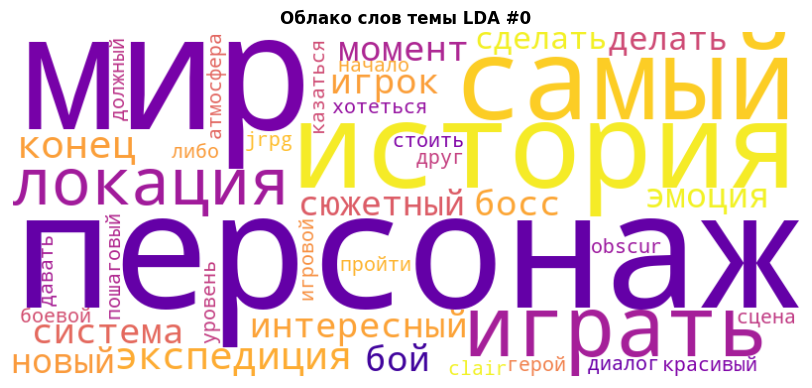

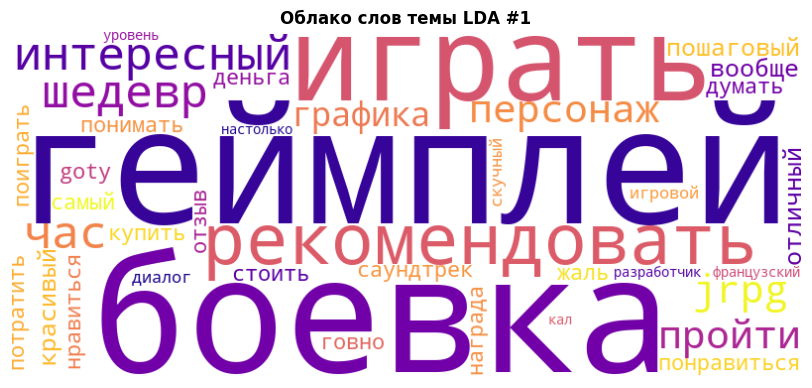

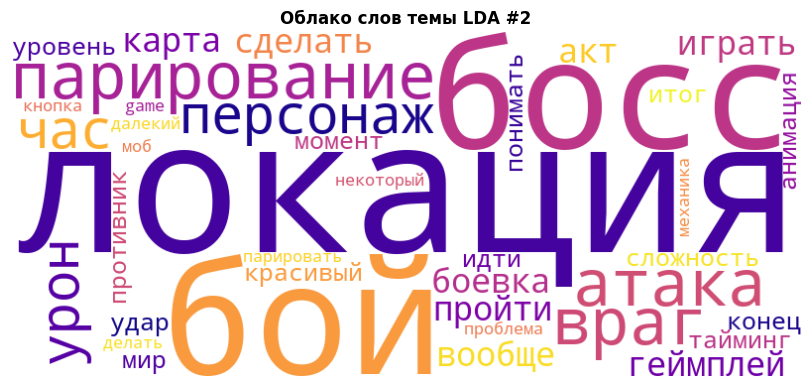

In [12]:
# Составим LDA облака
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# сначала на всем датасете
num_topics = 3
count_vec = CountVectorizer(max_df=0.2, min_df=10, stop_words=STOPWORDS)
dtm = count_vec.fit_transform(df["preproced"].apply(lambda x: ' '.join(x)))
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42, learning_method="batch")
lda.fit(dtm)

feature_names = count_vec.get_feature_names_out()

# WordClouds по топикам
topic_ids = [i for i in range(num_topics)]
for topic_id in topic_ids:
    top_words = [feature_names[i] for i in lda.components_[topic_id].argsort()[-40:][::-1]]
    wc = WordCloud(width=800, height=350, background_color="white", colormap="plasma").generate(" ".join(top_words))
    
    plt.figure(figsize=(11, 4.5))
    plt.imshow(wc, interpolation="bilinear"); plt.axis("off")
    plt.title(f"Облако слов темы LDA #{topic_id}", fontweight="bold")
    plt.show()

С max_df == 0.2 удалось найти что-то интересное. Удалось как-то разобрать, что, видимо, есть:
- Отзывы, которые больше про персонажей и сюжет
- Отзывы, которые больше про систему боя в игре
- И, возможно, где-то на пересечениях некоторых классов - локации и атмосфера

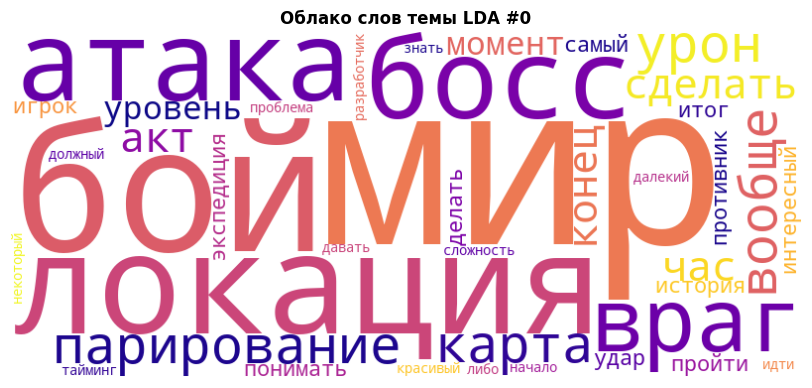

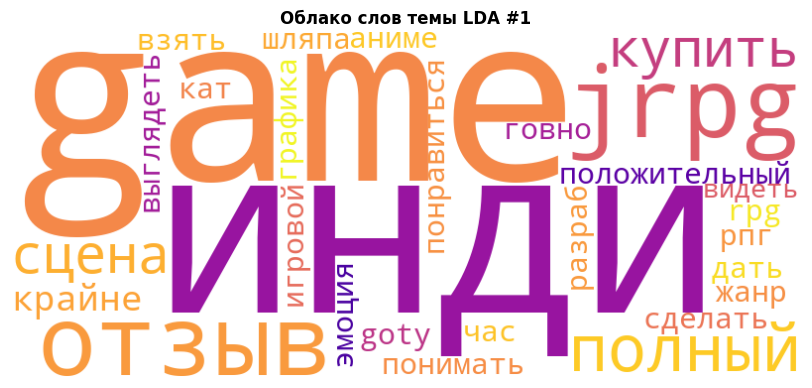

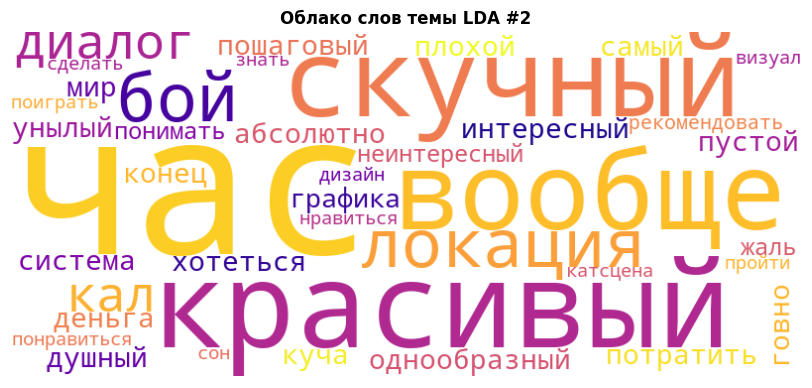

In [13]:
# Повторим на отрицательном классе
num_topics = 3
count_vec = CountVectorizer(max_df=0.2, min_df=10, stop_words=STOPWORDS)
dtm = count_vec.fit_transform(df[df['rating'] == 'Not Recommended']["preproced"].apply(lambda x: ' '.join(x)))
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42, learning_method="batch")
lda.fit(dtm)

feature_names = count_vec.get_feature_names_out()

# WordClouds по топикам
topic_ids = [i for i in range(num_topics)]
for topic_id in topic_ids:
    top_words = [feature_names[i] for i in lda.components_[topic_id].argsort()[-40:][::-1]]
    wc = WordCloud(width=800, height=350, background_color="white", colormap="plasma").generate(" ".join(top_words))
    
    plt.figure(figsize=(11, 4.5))
    plt.imshow(wc, interpolation="bilinear"); plt.axis("off")
    plt.title(f"Облако слов темы LDA #{topic_id}", fontweight="bold")
    plt.show()

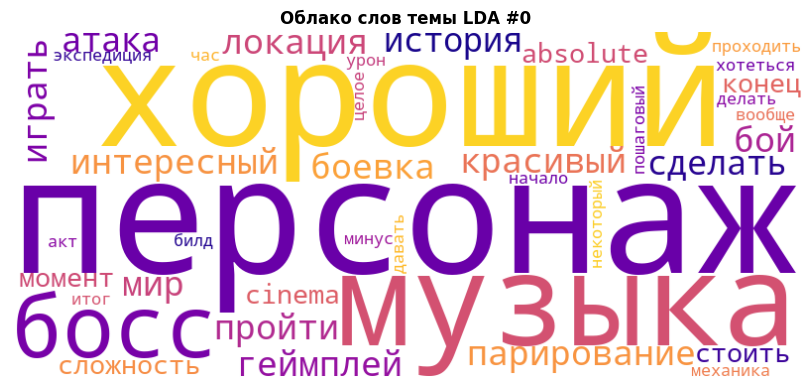

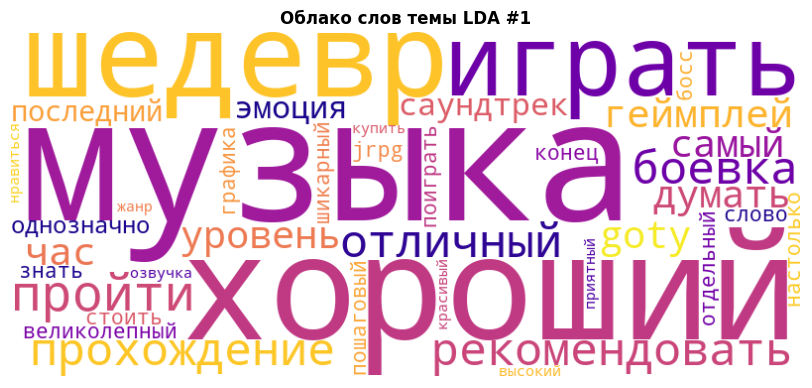

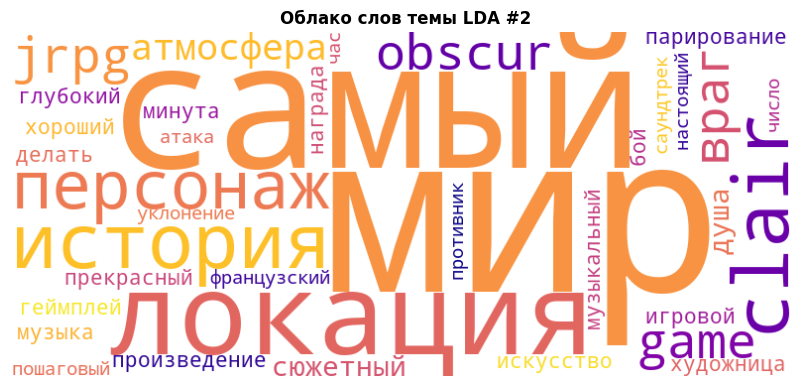

In [14]:
# Повторим на положительном классе
num_topics = 3
count_vec = CountVectorizer(max_df=0.2, min_df=10, stop_words=STOPWORDS)
dtm = count_vec.fit_transform(df[df['rating'] == 'Recommended']["preproced"].apply(lambda x: ' '.join(x)))
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42, learning_method="batch")
lda.fit(dtm)

feature_names = count_vec.get_feature_names_out()

# WordClouds по топикам
topic_ids = [i for i in range(num_topics)]
for topic_id in topic_ids:
    top_words = [feature_names[i] for i in lda.components_[topic_id].argsort()[-40:][::-1]]
    wc = WordCloud(width=800, height=350, background_color="white", colormap="plasma").generate(" ".join(top_words))
    
    plt.figure(figsize=(11, 4.5))
    plt.imshow(wc, interpolation="bilinear"); plt.axis("off")
    plt.title(f"Облако слов темы LDA #{topic_id}", fontweight="bold")
    plt.show()

Можно предположить, что отрицательные отзывы часто касаются боевой системы и локаций,
а положительные - атмосферы, музыки и сюжета.

In [15]:
# разделяем данные
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df["preproced"].apply(lambda x: ' '.join(x)), df["rating"],
    test_size=0.2, random_state=42, stratify=df["rating"]
)

In [16]:
# Обучение модели TF-IDF + LogisticRecression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import clear_output

vec = TfidfVectorizer(stop_words=STOPWORDS, ngram_range=(1, 1), min_df=1, max_features=4000)
pipe = Pipeline([
        ("vec", vec),
        ("clf", LogisticRegression(max_iter=1000, C=8)),
    ])
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, pred):.4f}')
print(f'F1-score: {f1_score(y_test, pred, pos_label='Not Recommended'):.4f}')
print(f'Recall: {recall_score(y_test, pred, pos_label='Not Recommended'):.4f}')
print(f'Precision {precision_score(y_test, pred, pos_label='Not Recommended'):.4f}')

Accuracy: 0.8375
F1-score: 0.7986
Recall: 0.7325
Precision 0.8779


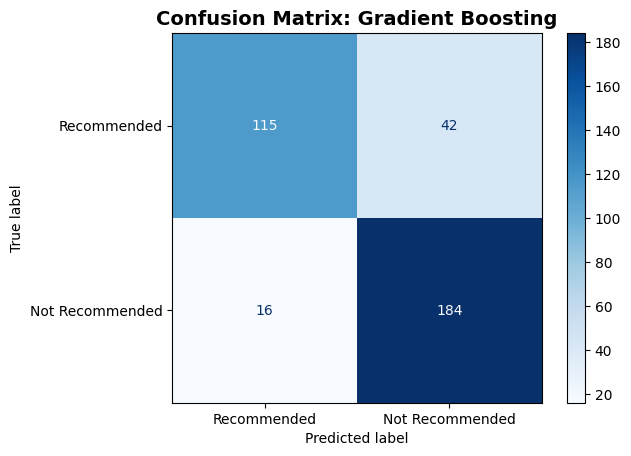

In [17]:
classes = ['Recommended', 'Not Recommended']
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Gradient Boosting', fontsize=14, fontweight='bold')
plt.show()

Удалось достигнуть accuracy > 0.8. Recall измерялся относительно отрицательных отзывов, потому что было интересно, на сколько хорошо получится предсказать именно их (Recall по положительным был 0.92).

Использовались следующие параметры: униграммы, min_df = 1, max_features = 4000, C = 8 для регрессии.

Вероятно recall просел, потому что в отрицательных отзывах довольно частотны слова, характерные для положительной тональности.

In [18]:
def make_prediction():
    '''Определяет характер отзыва с помощью модели'''
    text = [input('Введите текст:\n')]
    morph = MorphVocab()
    preproced = []
    for rev in text:
        rev = [tok.text for tok in list(tokenize(rev))]
        rev = ' '.join([morph.lemmatize(tok, morph(tok)[0].pos, {}) for tok in rev])
        preproced.append(rev)
    pred = pipe.predict(preproced)
    return pd.DataFrame({'review': text, 'label': pred})

In [22]:
make_prediction()

Введите текст:
 Игра суперская.


,review,label
0,Игра суперская.,Recommended
